# Modelling scRNA-seq Data with DeepDive

This tutorial demonstrates how to train a **DeepDive** model on single-cell RNA-seq data, evaluate latent structure, and iteratively incorporate previously unmodeled sources of variation through a second training pass.

Unlike ATAC-seq workflows, scRNA-seq data requires selecting **highly variable genes** and specifying a **Negative Binomial** count distribution.

---

## Imports

In [1]:
import scanpy as sc
import DeepDive
from scipy import sparse

## 1. Load and preprocess the dataset

We begin with an `AnnData` object containing single-cell RNA-seq profiles. In this example, we use a human pancreas dataset (`human_pancreas_norm_complexBatch.h5ad`), which spans multiple sequencing technologies and includes batch effects.

**scRNA-seq preprocessing steps:**

- **Highly variable genes (HVGs):** Select the most informative genes to reduce dimensionality and focus modelling on biologically relevant variation.
- **Count layer:** Raw integer counts are extracted from `adata.layers['counts']` and used as model input.
- **Sparse format:** The count matrix is converted to CSR sparse format for memory efficiency.

In [2]:
#https://docs.scvi-tools.org/en/1.3.3/tutorials/notebooks/multimodal/scarches_scvi_tools.html
adata = sc.read_h5ad('data/human_pancreas_norm_complexBatch.h5ad')



In [3]:
sc.pp.highly_variable_genes(
        adata
    )

In [4]:
adata.X = adata.layers['counts']
adata.X = sparse.csr_matrix(adata.X.astype(int)) 

In [5]:
adata = adata[:,adata.var.highly_variable]

In [6]:
adata

View of AnnData object with n_obs × n_vars = 16382 × 3545
    obs: 'tech', 'celltype', 'size_factors'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    layers: 'counts'

After preprocessing, `adata` contains 16,382 cells and 3,545 highly variable genes, ready for model training.

## 2. Define model and training parameters

We specify model hyperparameters and training settings.

**Model parameters**

- `n_decoders`: Number of decoders used for reconstruction.
- `n_epochs_pretrain_ae`: Number of epochs to pretrain the autoencoder before adversarial training begins.

**Training parameters**

- `max_epoch`: Maximum number of training epochs.
- `batch_size`: Number of cells per training batch.
- `shuffle`: Whether to shuffle the training data each epoch.
- `distribution`: The count distribution assumed by the decoder. Use `'NB'` (Negative Binomial) for scRNA-seq count data, which models overdispersion typical in gene expression.

In [7]:
n_decoders = 5  
model_params = {
    'n_epochs_pretrain_ae' : 200*n_decoders,
    'n_decoders' : n_decoders,
}
train_params = {
    'max_epoch' : 300*n_decoders, 
    'batch_size' : 1024, 
    'shuffle' : True,
    'distribution' : 'NB'
    
}

## 3. Specify covariates

DeepDive disentangles known covariates from biological variation. Here, we specify sequencing technology (`tech`) as the only discrete covariate, as this dataset spans multiple platforms with associated batch effects.

In [8]:
discrete_covriate_keys = ['tech']


## 4. Initialize and train the model

The model is initialized with the AnnData object and covariate specifications, then trained using the defined parameters.

In [9]:
model = DeepDive.DeepDive(adata = adata, 
                        discrete_covariate_names = discrete_covriate_keys,
                        **model_params
                       )

In [10]:
model.train_model(adata, None, 
                  **train_params)

Epoch Train [1500 / 1500]: 100%|██████████| 16/16 [00:00<00:00, 54.60it/s, ETA=01d:00h:06:m02s|01d:00h:06:m02s, kl_loss=12, recon_loss=1.91e+3]  


Training history (loss curves) can be visualized with:

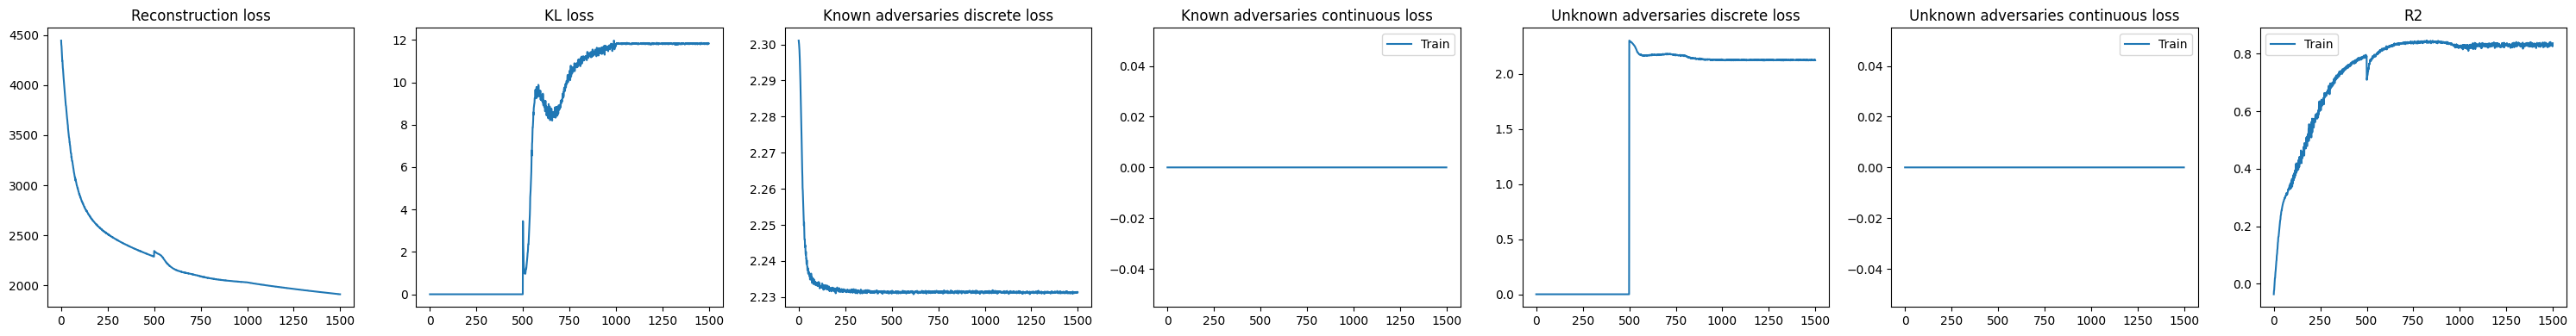

In [11]:
DeepDive.plot_history(model)

The KL divergence remains relatively high, suggesting that substantial variation is still being captured in the residual (unknown) component of the model. This indicates that not all sources of structure in the data are explained by the provided covariates, and that additional biological or technical factors may still be influencing chromatin accessibility.

## 5. Evaluate latent variation

To assess whether unmodeled sources of variation influence gene expression, we examine the learned latent representation.

Here, we compute the latent embedding without adding additional covariates and visualize it using UMAP. Clustering in this space may indicate residual structure not explained by the specified covariates (e.g., cell type, uncharacterized batch effects).

In [12]:
latent = model.get_latent(adata, covars_to_add=[])

In [13]:
sc.pp.neighbors(latent)

In [14]:
sc.tl.umap(latent)

In [15]:
sc.tl.leiden(latent, resolution = 0.2)

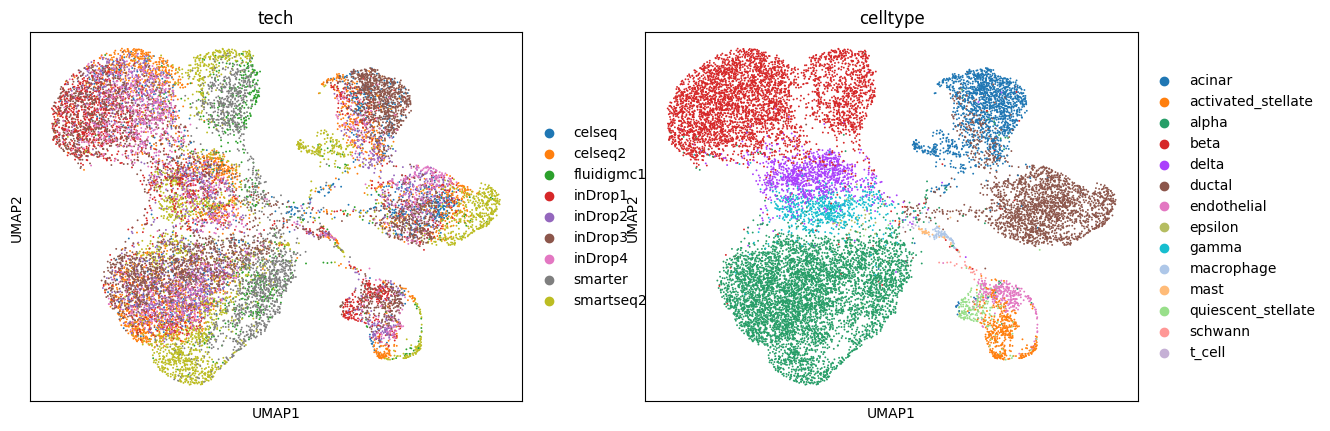

In [16]:
sc.pl.umap(latent, color = discrete_covriate_keys + ['celltype'])

## Summary

This notebook covers the complete workflow for modelling scRNA-seq data with DeepDive:

- Preparing a scRNA-seq dataset using highly variable gene selection and raw count extraction
- Defining model parameters with a Negative Binomial distribution appropriate for RNA counts
- Training DeepDive to disentangle sequencing technology effects